In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (12, 8)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
x = np.array([2,3,4,5]).reshape(-1,2,order = 'C')
x #make columns
y = np.array([1,2])
x,y

(array([[2, 3],
        [4, 5]]),
 array([1, 2]))

In [ ]:
z = x @ y #vector
z

array([ 8, 14])

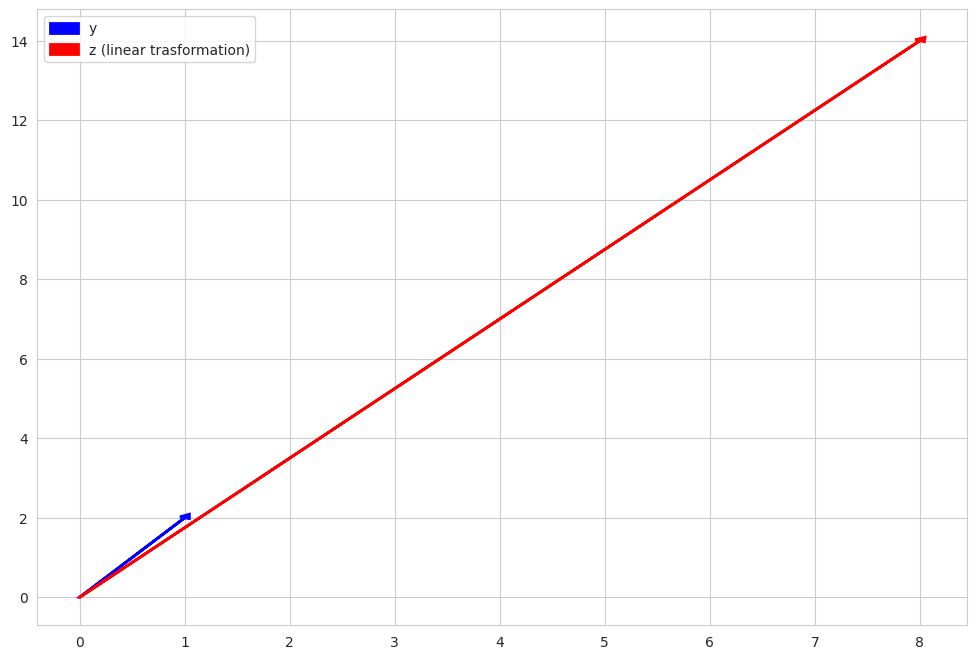

In [ ]:
plt.arrow(0, 0, y[0], y[1], head_width=0.1, head_length=0.1,
          fc='blue', ec='blue', linewidth=2, label='y')

# Plot target z vector
plt.arrow(0, 0, z[0], z[1], head_width=0.1, head_length=0.1,
          fc='red', ec='red', linewidth=2, label='z (linear trasformation)') #stretch and rotate
plt.legend()
plt.show()

# blue = y
# red = z (linear transformation)
#make it rotate - stretch - rotate again  (every can stretch by function) = eigendecompretion

In [ ]:
y_angle = np.arctan2(y[1], y[0])
print(np.degrees(y_angle))
#63 độ line xanh -> nên giờ phải rotate thành line đỏ 45 độ


z_angle = np.arctan2(z[1], z[0])
print(np.degrees(z_angle))

rotation_angle = y_angle - z_angle
print(np.degrees(rotation_angle)) # the change

63.43494882292201
60.25511870305778
3.1798301198642234


In [ ]:
#Rotation Matrix
#R = [cos(theta), -sin(theta),sin(theta),cos(theta)]
R = np.array([[np.cos(rotation_angle), -np.sin(rotation_angle)],
              [np.sin(rotation_angle), np.cos(rotation_angle)]])

In [ ]:
y_rotated = R @ y
y_rotated

array([0.88752031, 2.05239073])

In [ ]:
# how many time we need to stretch do dai khac nhau
# |z| = can binh phuong z0+z1

In [ ]:
norm_z = np.sqrt(z[0]**2 + z[1]**2) # distant
norm_z

np.float64(16.1245154965971)

In [ ]:
norm_y = np.sqrt(y_rotated[0]**2 + y_rotated[1]**2) #
norm_y

np.float64(2.23606797749979)

In [ ]:
stretch_factor = norm_z / norm_y
stretch_factor #we have to stretch 7 times

np.float64(7.211102550927977)

#Eigenvectors and Eigenvalues :

#special vector : eigenvectors bc (normal rotate and stretch) do not change direcction stretch only

Xv = Biv  same matrix


**Eigenvector là gì?**

Eigenvector là vector mà khi nhân với ma trận thì hướng của nó không đổi.


**Eigenvalue là gì?**

Eigenvalue là hệ số cho biết eigenvector bị stretch bao nhiêu lần.

In [ ]:
x

array([[2, 3],
       [4, 5]])

In [ ]:
eval,evec = np.linalg.eig(x)

In [ ]:
eval,evec

(array([-0.27491722,  7.27491722]),
 array([[-0.79681209, -0.49436913],
        [ 0.60422718, -0.86925207]]))

In [ ]:
ez_1 =evec[:,1]

In [ ]:
ez1 = -(x @ evec[:,1])
ez1

array([3.59649447, 6.32373687])

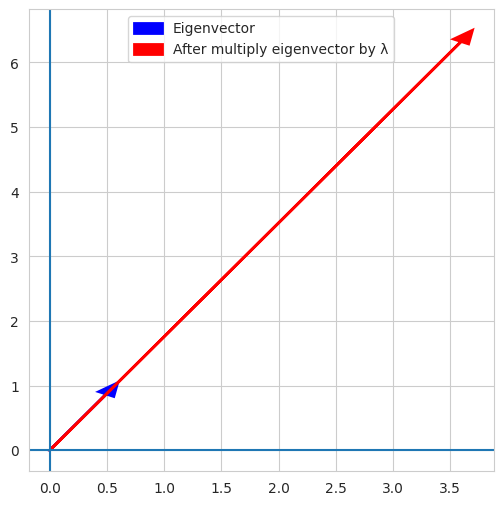

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

v = ez_1.copy()

# đảm bảo vector hướng lên
if v[1] < 0:
    v = -v

z = ez1.copy()

# đảm bảo vector sau transform cũng hướng lên
if z[1] < 0:
    z = -z

plt.figure(figsize=(6,6))

plt.arrow(0,0,v[0],v[1],
          head_width=0.15,
          head_length=0.2,
          fc='blue',ec='blue',
          linewidth=2)

plt.arrow(0,0,z[0],z[1],
          head_width=0.15,
          head_length=0.2,
          fc='red',ec='red',
          linewidth=2)

plt.grid(True)
plt.axhline(0)
plt.axvline(0)

plt.legend(["Eigenvector","After multiply eigenvector by λ"])

plt.show()

#EIGEN DECOMPOSITION


x = P * D * P-1

In [ ]:
x

array([[2, 3],
       [4, 5]])

In [ ]:
eigenvals,eigenvec = np.linalg.eig(x)

In [ ]:
eigenvals,eigenvec

(array([-0.27491722,  7.27491722]),
 array([[-0.79681209, -0.49436913],
        [ 0.60422718, -0.86925207]]))

In [ ]:
P = eigenvec
D = np.diag(eigenvals)
P_inv = np.linalg.inv(P)

In [ ]:
P @ D @ P_inv #we decompose

array([[2., 3.],
       [4., 5.]])

In [ ]:
# nói chung là tìm cái vector show tốt nhất (rotate )
# reduce dimension to maxmize variance data and find the angle
#difference cut -> different view  (we do not fix) - combine and make new
#move center -> calculate variance (mean center)
#we have to find angle to flip data best

# x1,x2,x3 -> maximize z =(bx)
# b x (x1,x2,x3) -> maximize variance rồi


#function

In [ ]:
xc = x -np.mean(x,axis = 0) #tính mean của từng cột
xc #data demean

array([[-1., -1.],
       [ 1.,  1.]])

In [ ]:
sigma = np.cov(xc,rowvar = False) #chỉnh lại type
sigma #cov matrix

array([[2., 2.],
       [2., 2.]])

In [ ]:
eigenvals,eigenvec = np.linalg.eig(sigma)

In [ ]:
eigenvals, eigenvec

(array([4.0000000e+00, 4.4408921e-16]),
 array([[ 0.70710678, -0.70710678],
        [ 0.70710678,  0.70710678]]))

In [ ]:
from numpy.linalg import eig
P = eigenvec #đây là các hướng đặc biệt của ma trận.
D = np.diag(eigenvals) #eigenvalue cho biết stretch bao nhiêu theo eigenvector.
P_inv = np.linalg.inv(P)

In [ ]:
P @ D @ P_inv

array([[2., 2.],
       [2., 2.]])

In [ ]:
 P_inv

array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]])

In [ ]:
print(P.T) # = P_inv

array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]])

In [ ]:
#how to find p1

print(eigenvals)

[4.0000000e+00 4.4408921e-16]


In [ ]:
eigenvec
#p1 là cái cột đầu (0.70710678,0.70710678)

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [ ]:
p1 = xc @ eigenvec[:,0]

In [ ]:
p1 #create the new one

array([-1.41421356,  1.41421356])

#Practice

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=1) #lấy p1
pca.fit(x)

PCA(n_components=1)

In [ ]:
eigenval = pca.explained_variance_
eigenval

array([4.])

In [ ]:
eigenvec = pca.components_.T
eigenvec

array([[0.70710678],
       [0.70710678]])

In [ ]:
pc1 = xc @ eigenvec
pc1

array([[-1.41421356],
       [ 1.41421356]])

#EXAMPLE


In [ ]:
data = {
    'X1': [2.5, 0.5, 2.2, 1.9, 3.1, 2.3, 2, 1, 1.5, 1.1],
    'X2': [2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9]
}

X = np.array([data['X1'], data['X2']]).T

In [ ]:
X.shape

(10, 2)

In [ ]:
##Xdeman
xc1 = X -np.mean(X,axis = 0)
xc1

array([[ 0.69,  0.49],
       [-1.31, -1.21],
       [ 0.39,  0.99],
       [ 0.09,  0.29],
       [ 1.29,  1.09],
       [ 0.49,  0.79],
       [ 0.19, -0.31],
       [-0.81, -0.81],
       [-0.31, -0.31],
       [-0.71, -1.01]])

In [ ]:
#COV
cov_matrix = np.cov(xc1.T)
cov_matrix

array([[0.61655556, 0.61544444],
       [0.61544444, 0.71655556]])

In [ ]:
#eigvalue-vec
eig_val,eig_vec = np.linalg.eig(cov_matrix)
eig_val,eig_vec

(array([0.0490834 , 1.28402771]),
 array([[-0.73517866, -0.6778734 ],
        [ 0.6778734 , -0.73517866]]))

In [ ]:
pca1 = eig_vec[:,1]
pca1 = xc1 @ eigenvec



(10, 1)

#step 2

In [ ]:
pca1 = PCA(n_components=1) #lấy p1
pca1.fit(X)

PCA(n_components=1)

In [ ]:
eigenval1 = pca1.explained_variance_
eigenval1

array([1.28402771])

In [ ]:
eigenvec1 = pca1.components_.T
eigenvec1

array([[0.6778734 ],
       [0.73517866]])

In [ ]:
pc1 = xc1 @ eigenvec1
pc1

array([[ 0.82797019],
       [-1.77758033],
       [ 0.99219749],
       [ 0.27421042],
       [ 1.67580142],
       [ 0.9129491 ],
       [-0.09910944],
       [-1.14457216],
       [-0.43804614],
       [-1.22382056]])

#Curse of Dimensionality


# reduce dimension (can keep object )
giống cái map mà k hiển thị người với nhà , tree

In [ ]:
from sklearn.datasets import load_wine
dataset = load_wine()
X = dataset.data
y = dataset.target
X.shape


(178, 13)

In [ ]:
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

#Split dataset innto Train and Test set

In [ ]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

#applying PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components='mle',random_state=123)

X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)

In [ ]:
pca.n_components_

np.int64(8)

In [ ]:
pca.explained_variance_ratio_.sum()

np.float64(0.9238662132068882)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log = LogisticRegression()
log.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = log.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[12,  0,  0],
       [ 1, 13,  0],
       [ 0,  0, 10]])

In [ ]:
accuracy_score(y_test, y_pred)

0.9722222222222222

#From eigendecomposition to singular value decomposition

In [ ]:
x = np.array([3,0,4,5],order = 'C').reshape(-1,2)
x

array([[3, 0],
       [4, 5]])

In [ ]:
U,S,V = np.linalg.svd(x)

In [ ]:
U @ np.diag(S) @ V

array([[3.00000000e+00, 1.33807967e-15],
       [4.00000000e+00, 5.00000000e+00]])

In [ ]:
V

array([[-0.70710678, -0.70710678],
       [-0.70710678,  0.70710678]])

#Single Value Decomposition

In [ ]:
from matplotlib.pyplot import imshow

In [ ]:
D = np.array([[0,1,1,0,1,1,0],
              [1,1,1,1,1,1,1],
              [1,1,1,1,1,1,1],
              [0,1,1,1,1,1,0],
              [0,0,1,1,1,0,0],
              [0,0,0,1,0,0,0]
             ])

In [ ]:
D.shape

(6, 7)

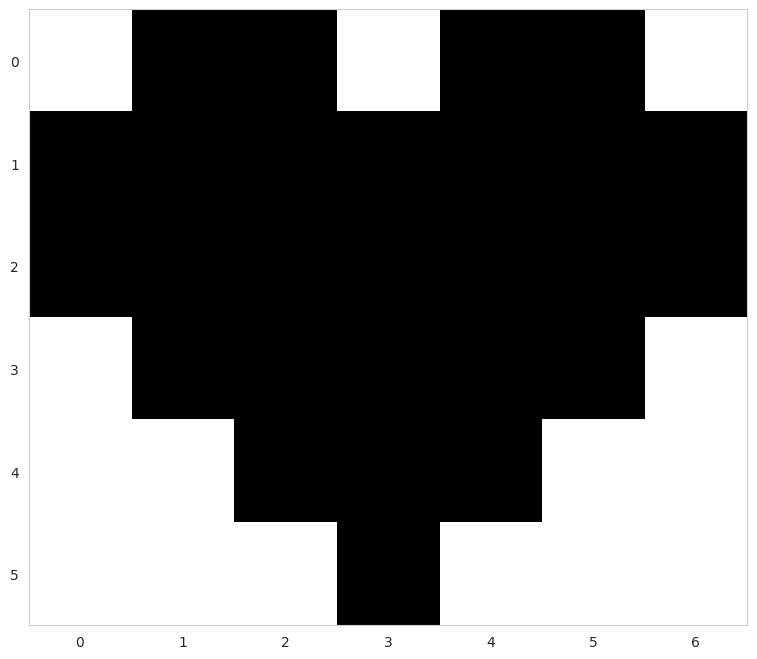

In [ ]:
plt.imshow(D,cmap='gray_r')
plt.grid(False)
plt.show()

In [ ]:
U,S,V = np.linalg.svd(D,full_matrices=False)
print(U)
print(S)
print(V)

[[ 3.61249460e-01 -4.38468638e-16  7.30296743e-01 -5.32180543e-02
  -2.63150853e-01  5.13891975e-01]
 [ 5.41874189e-01  3.53553391e-01 -2.73861279e-01 -7.98270815e-02
   6.29386561e-01  3.22292657e-01]
 [ 5.41874189e-01  3.53553391e-01 -2.73861279e-01 -7.98270815e-02
  -6.29386561e-01 -3.22292657e-01]
 [ 4.45394592e-01 -3.53553391e-01  2.73861279e-01  5.17967494e-01
   2.63150853e-01 -5.13891975e-01]
 [ 2.77104327e-01 -7.07106781e-01 -1.82574186e-01 -6.24403602e-01
   2.49800181e-16  1.62196645e-16]
 [ 8.41451321e-02 -3.53553391e-01 -4.56435465e-01  5.71185548e-01
  -2.63150853e-01  5.13891975e-01]]
[4.73981604e+00 1.41421356e+00 1.41421356e+00 7.30851490e-01
 1.49190666e-16 1.82188799e-17]
[[ 2.28647772e-01  3.98832447e-01  4.57295545e-01  3.98832447e-01
   4.57295545e-01  3.98832447e-01  2.28647772e-01]
 [ 5.00000000e-01  2.50000000e-01 -2.50000000e-01 -5.00000000e-01
  -2.50000000e-01  2.50000000e-01  5.00000000e-01]
 [-3.87298335e-01  3.22748612e-01  1.93649167e-01 -6.45497224e-01


In [ ]:
U.shape,S.shape,V.shape
#rotate vector , stretch value , rotate vector

((6, 6), (6,), (6, 7))

In [ ]:
E =(U @ np.diag(S) @V).round(2)

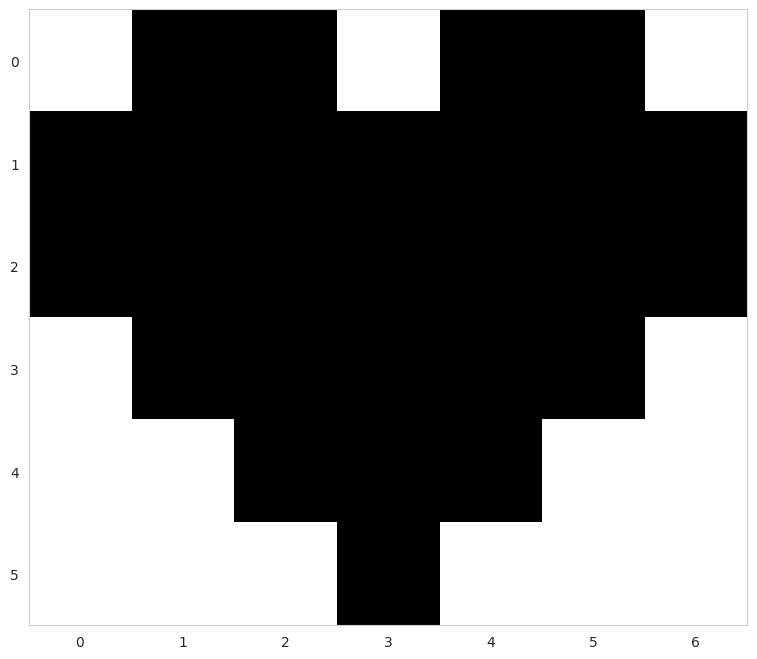

In [ ]:
plt.imshow(E,cmap='gray_r')
plt.grid(False)
plt.show()

In [ ]:
D

array([[0, 1, 1, 0, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0]])

In [ ]:
#giữ cái quan trọng

In [ ]:
S.round(2)

array([4.74, 1.41, 1.41, 0.73, 0.  , 0.  ])

In [ ]:
p1 = S[0] * np.outer(U[:,0],V[0,:])
p1.shape

(6, 7)

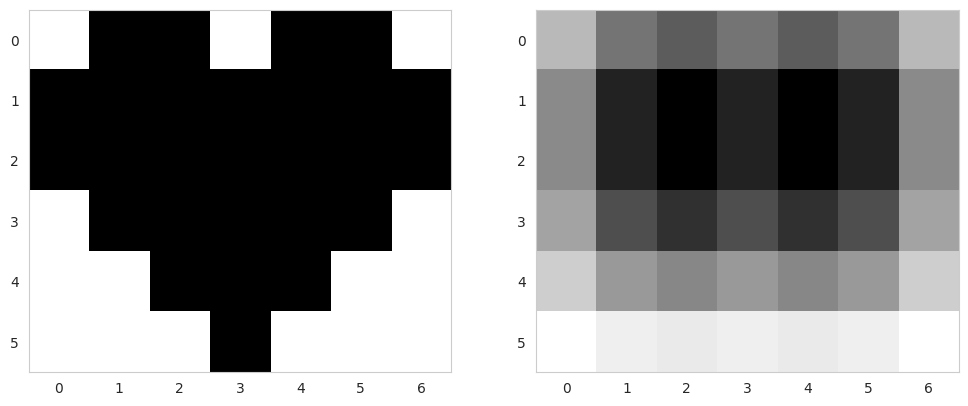

In [ ]:
plt.subplot(1,2,1)
plt.imshow(D,cmap='gray_r')
plt.grid(False)

plt.subplot(1,2,2)
plt.imshow(p1,cmap='gray_r')
plt.grid(False)
plt.show()
#

In [ ]:
p2 = p1 + S[1]*np.outer(U[:,1],V[1,:])

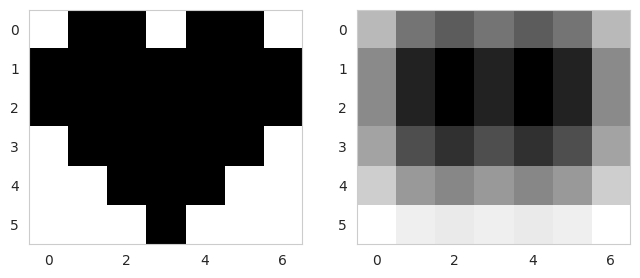

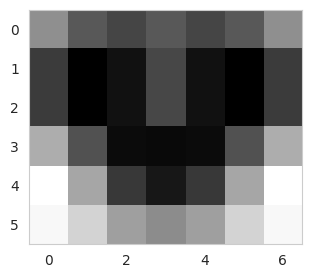

In [ ]:
plt.subplot(1,3,1)
plt.imshow(D,cmap='gray_r') #gốc
plt.grid(False)

plt.subplot(1,3,2)
plt.imshow(p1,cmap='gray_r') # 1 D
plt.grid(False)
plt.show()


plt.subplot(1,3,3)
plt.imshow(p2,cmap='gray_r') # 2 D
plt.grid(False)

plt.show()


In [ ]:
p3 = p1 + p2 + S[2]*np.outer(U[:,2],V[2,:])

In [ ]:
p4 =p1 + p2 + p3 + S[3]*np.outer(U[:,3],V[3,:])

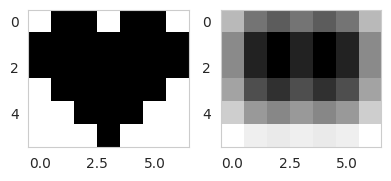

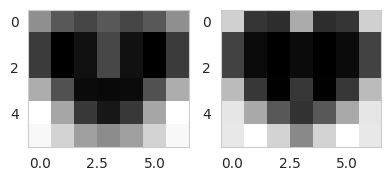

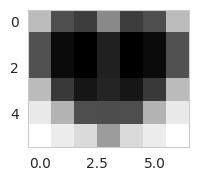

In [ ]:
plt.subplot(1,5,1)
plt.imshow(D,cmap='gray_r') #gốc
plt.grid(False)

plt.subplot(1,5,2)
plt.imshow(p1,cmap='gray_r') # 1 D
plt.grid(False)
plt.show()


plt.subplot(1,5,3)
plt.imshow(p2,cmap='gray_r') # 2 D
plt.grid(False)



plt.subplot(1,5,4)
plt.imshow(p3,cmap='gray_r') # 1 D
plt.grid(False)
plt.show()


plt.subplot(1,5,5)
plt.imshow(p4,cmap='gray_r') # 2 D
plt.grid(False)

plt.show()


#Economic Complexity

In [2]:
import pandas as pd
M = pd.DataFrame(
    [
        [1, 0, 1, 1, 1, 1],  # Country A VietNam have competitive of import thing
        [1, 1, 0, 0, 0, 0],  # Country B
        [1, 1, 1, 0, 1, 0],  # Country C
        [0, 0, 1, 1, 1, 1],  # Country D
        [1, 0, 0, 0, 0, 0],  # Country E
    ],
    index=["Vietnam", "Thai", "Korea", "Japan", "Taiwan"],
    columns=["Coffee", "Cocoa", "Textiles", "Steel", "Chemicals", "Electronics"]
)

print(M)

         Coffee  Cocoa  Textiles  Steel  Chemicals  Electronics
Vietnam       1      0         1      1          1            1
Thai          1      1         0      0          0            0
Korea         1      1         1      0          1            0
Japan         0      0         1      1          1            1
Taiwan        1      0         0      0          0            0


In [3]:
from sklearn.decomposition import TruncatedSVD

In [4]:
svd = TruncatedSVD(2,random_state=123) #5 by 2 matrix => p2

In [5]:
country_factors = svd.fit_transform(M)

In [6]:
country_factors

array([[ 2.15861481, -0.3915091 ],
       [ 0.66016413,  1.17103858],
       [ 1.66670487,  0.91065331],
       [ 1.71000889, -1.00690846],
       [ 0.44860592,  0.61539936]])

In [7]:
#boi vi sx nhieu qua nen giam dimension de xem
products_factors = svd.components_
products_factors

array([[ 0.44860592,  0.21155821,  0.50327037,  0.35173408,  0.50327037,
         0.35173408],
       [ 0.61539936,  0.55563922, -0.13019263, -0.3732616 , -0.13019263,
        -0.3732616 ]])

In [10]:
M_hat = country_factors @ products_factors
M_hat = pd.DataFrame(M_hat, index=M.index, columns=M.columns)
M_hat

,Coffee,Cocoa,Textiles,Steel,Chemicals,Electronics
Vietnam,0.727433,0.239135,1.137338,0.905394,1.137338,0.905394
Thai,1.016810,0.790338,0.179780,-0.204902,0.179780,-0.204902
Korea,1.308109,0.858600,0.720243,0.246325,0.720243,0.246325
Japan,0.147469,-0.197711,0.991689,0.977309,0.991689,0.977309
Taiwan,0.579964,0.436846,0.145650,-0.071915,0.145650,-0.071915


##Recommedation System

In [12]:
import numpy as np
R = pd.DataFrame(
    [
        [5, 4, np.nan, 1, np.nan],
        [4, np.nan, np.nan, 1, 2],
        [1, 1, np.nan, 5, 4],
        [np.nan, 2, 4, 4, 5],
        [np.nan, 1, 5, 4, np.nan],
    ],
    index=["User1", "User2", "User3", "User4", "User5"],
    columns=["MovieA", "MovieB", "MovieC", "MovieD", "MovieE"]
)

In [13]:
R

,MovieA,MovieB,MovieC,MovieD,MovieE
User1,5.0,4.0,NaN,1,NaN
User2,4.0,NaN,NaN,1,2.0
User3,1.0,1.0,NaN,5,4.0
User4,NaN,2.0,4.0,4,5.0
User5,NaN,1.0,5.0,4,NaN


In [15]:
from sklearn.impute import SimpleImputer

In [17]:
imputer = SimpleImputer(strategy='mean')
R_filled = imputer.fit_transform(R)
R_filled

array([[5.        , 4.        , 4.5       , 1.        , 3.66666667],
       [4.        , 2.        , 4.5       , 1.        , 2.        ],
       [1.        , 1.        , 4.5       , 5.        , 4.        ],
       [3.33333333, 2.        , 4.        , 4.        , 5.        ],
       [3.33333333, 1.        , 5.        , 4.        , 3.66666667]])

In [22]:
k = 2 #2 dimmension
svd = TruncatedSVD(n_components=k, random_state=123)

In [21]:
user_factors = svd.fit_transform(R_filled)
user_factors.shape

(5, 2)

In [24]:
svd.fit(R_filled)
item_factors = svd.components_
item_factors

array([[ 0.43638664,  0.26329877,  0.58563614,  0.39857206,  0.48827357],
       [-0.55654845, -0.41513286, -0.03105173,  0.69255703,  0.19318147]])

In [27]:
R_hat = user_factors @ item_factors
R_hat = pd.DataFrame(R_hat, index=R.index, columns=R.columns)
R_hat

,MovieA,MovieB,MovieC,MovieD,MovieE
User1,5.288017,3.443031,4.818686,1.008454,3.320466
User2,3.920019,2.533157,3.745078,1.037747,2.658622
User3,1.438621,0.620164,4.167010,5.065620,4.158639
User4,3.132296,1.816404,4.866809,3.973486,4.260667
User5,2.918452,1.677342,4.670386,3.930091,4.124613


In [28]:
R

,MovieA,MovieB,MovieC,MovieD,MovieE
User1,5.0,4.0,NaN,1,NaN
User2,4.0,NaN,NaN,1,2.0
User3,1.0,1.0,NaN,5,4.0
User4,NaN,2.0,4.0,4,5.0
User5,NaN,1.0,5.0,4,NaN
